# Overview

## Background

pada pengujian out study ini akan di bagi berdsarkan algoritma optimasi, time frame(daily) untuk mendapatkan model terbaik dalam forecasting penjualan obat berdasarkan kategori obat tersebut. model utama yang digunakan untuk melakukan forecasting pada our study ini yakni model LRXGBoost(linear regression + XGBoost). adapun beberapa hyperparameter yang digunakan pada model GRNN ini untuk mencari approach terbaik diantaranya n_estimator, learning_rate, dan max_depth. hyperparameter ini yang akan di cari menggunakan beberapa algoritma tunning hyperparameter(grid search, optuna, pso, egeo), selain activation distance sigma juga di tunning untuk mencari paramater terbaik dari setiap kategori obat pada model XGBoost.

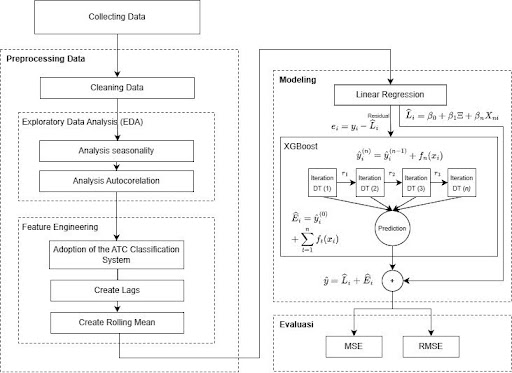

# Load Lib

In [6]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
import optuna
from pyswarms.single.global_best import GlobalBestPSO
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from src.utils.geo import GEO
import seaborn as sns

optuna.logging.set_verbosity(optuna.logging.ERROR)

# Load Data

In [8]:
pathTraining = '../data/raw/pharma-sales/salesweekly.csv'
data = pd.read_csv(pathTraining)
data.head()

distances = ["euclidean", "manhattan", "chebyshev", "minkowski", "hamming", "mahalanobis"]
categories = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Preprocessing

## Cleaning Data

## Exploratory Data Analysis (EDA)

### Analysis seasonality

Pola musiman dapat diamati secara lebih rinci melalui visualisasi boxplot. Dari hasil analisis, terlihat bahwa kategori R03, R06, dan N02BE menunjukkan adanya pola musiman yang jelas, menandakan bahwa penjualan pada kategori tersebut dipengaruhi oleh periode waktu tertentu (misalnya bulanan atau musiman tahunan).

Selain itu, kategori R03 dan N05C memiliki jumlah outlier yang lebih banyak dibandingkan kategori lainnya. Hal ini mengindikasikan bahwa variasi penjualan pada kedua kategori tersebut lebih tinggi dan lebih sulit diprediksi secara konsisten dibandingkan kategori lain.

2025-10-18 15:58:33,045 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-18 15:58:33,059 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-18 15:58:33,182 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-18 15:58:33,193 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-18 15:58:33,

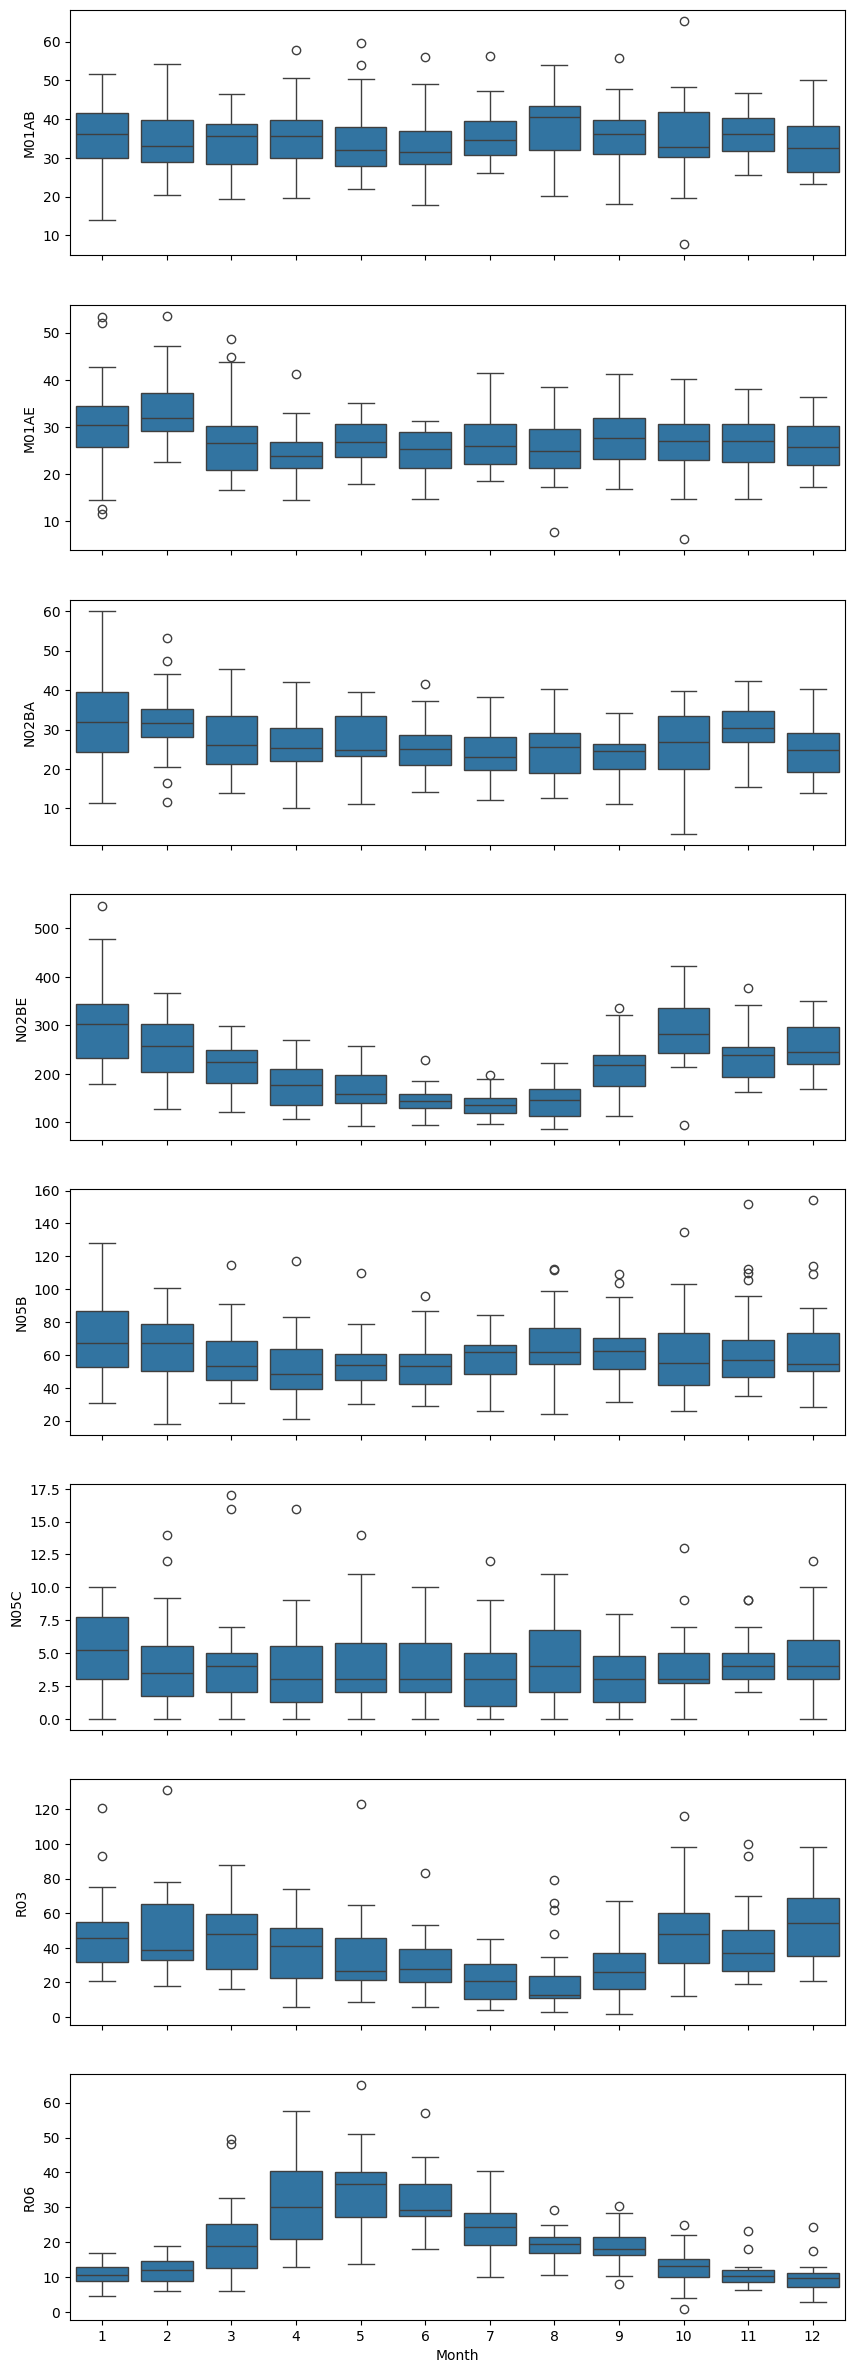

In [9]:
fig, axes = plt.subplots(8, 1, figsize=(10, 30), sharex=True)
data['Month'] = pd.to_datetime(data['datum']).dt.month
for name, ax in zip(['M01AB','M01AE','N02BA','N02BE', 'N05B','N05C','R03','R06'], axes):
    sns.boxplot(data=data, x='Month', y=name, ax=ax)

### Analysis Partial Autocorelation

Karena analisa seasonality tidak terlalu bagus hasilnya dan hanya menghasilkan pola musiman bulanan di beberapa kategori obat aja, sehingga peneliti melakukan analisa PACF. Analisis Partial Autocorrelation (PACF) digunakan untuk memahami hubungan langsung antara suatu observasi dengan observasi pada lag tertentu, dengan menghilangkan pengaruh lag di antara keduanya.
Berbeda dengan ACF yang mengukur korelasi total antar waktu, PACF hanya menampilkan korelasi parsial — yaitu seberapa besar kontribusi unik dari masing-masing lag terhadap nilai saat ini.

PACF dihitung menggunakan koefisien Pearson, sehingga analisis ini paling relevan untuk data dengan distribusi normal (Gaussian).
Plot PACF memperlihatkan lag pada sumbu-x dan nilai korelasi parsial pada sumbu-y (antara -1 hingga 1).
Batas interval kepercayaan 95% biasanya ditampilkan dalam bentuk pita atau garis horizontal. Nilai korelasi parsial yang berada di luar batas tersebut menunjukkan adanya hubungan signifikan langsung pada lag tertentu.

Analisis PACF membantu mengidentifikasi lag signifikan yang dapat dimanfaatkan sebagai fitur input dalam model Linear Regresi, XGBoost, dan GRNN, terutama ketika pola musiman tidak terlalu jelas terdeteksi dari analisis seasonality sebelumnya.

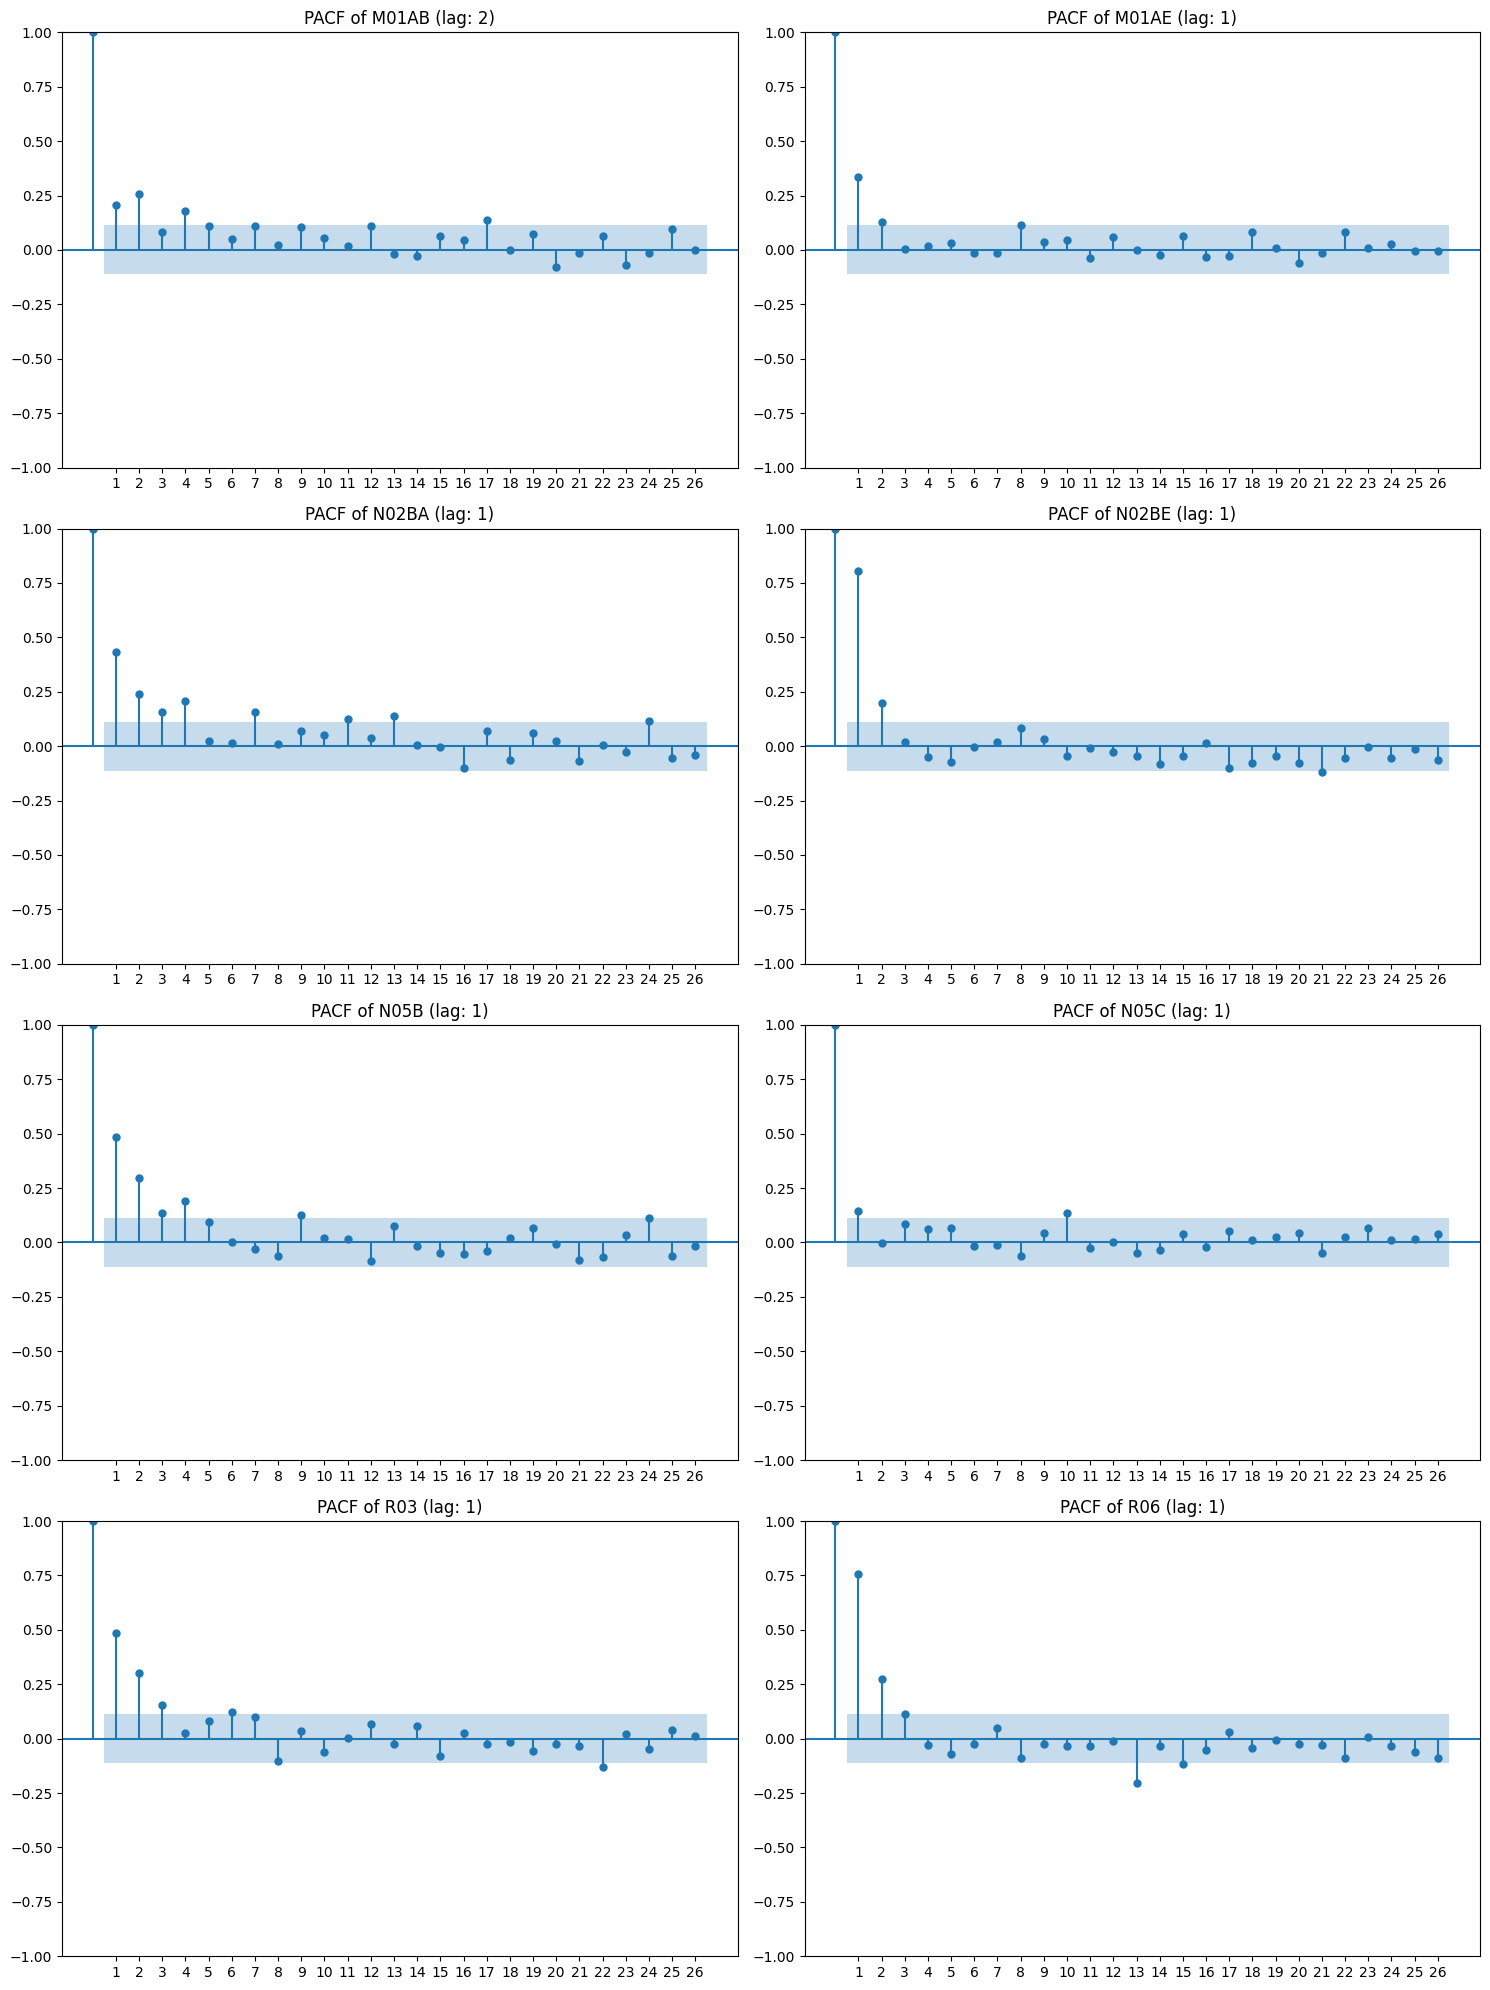

In [10]:
max_lags = {}

# Create a 2x4 subplot
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot PACF for each category
for i, category in enumerate(categories):
    pacf_values = pacf(data[category], nlags=26)
    max_lag = np.argmax(pacf_values[1:]) + 1  # Ignore lag 0 and add 1 for correct lag
    max_lags[category] = max_lag
    
    plot_pacf(data[category], lags=26, ax=axes[i])
    axes[i].set_title(f'PACF of {category} (lag: {max_lag})')
    axes[i].set_xticks(range(1, 27))  # Set x-axis ticks for PACF
    axes[i].set_xticklabels(range(1, 27))  # Set x-axis labels for PACF

plt.tight_layout()
plt.show()

##  Feature Engineering

### Adoption of the ATC Classification System

Dataset awal terdiri dari **600.000 data transaksi** yang dikumpulkan selama **6 tahun (periode 2014–2019)**, mencakup informasi mengenai **tanggal dan waktu penjualan**, **nama merek obat farmasi**, serta **jumlah penjualan**.

Berdasarkan hasil wawancara dengan apoteker, diputuskan bahwa **objek analisis dan peramalan akan difokuskan pada kategori obat**, bukan pada masing-masing obat secara individual. Oleh karena itu, kelompok obat terpilih sebanyak **57 jenis obat** diklasifikasikan ke dalam **8 kategori berdasarkan sistem klasifikasi ATC (Anatomical Therapeutic Chemical Classification System)** sebagai berikut:

* **M01AB** – Produk antiinflamasi dan antireumatik nonsteroid, turunan asam asetat dan zat terkait
* **M01AE** – Produk antiinflamasi dan antireumatik nonsteroid, turunan asam propionat
* **N02BA** – Analgesik dan antipiretik lainnya, turunan asam salisilat
* **N02BE/B** – Analgesik dan antipiretik lainnya, turunan pirazolon dan anilida
* **N05B** – Obat psiko-leptik, golongan ansiolitik
* **N05C** – Obat psiko-leptik, golongan hipnotik dan sedatif
* **R03** – Obat untuk penyakit saluran napas obstruktif
* **R06** – Antihistamin untuk penggunaan sistemik

Fitur berupa **kode ATC** kemudian ditambahkan ke dalam dataset. Model data selanjutnya **ditransformasikan sesuai ilustrasi pada gambar di bawah**, dan **data diubah menjadi bentuk deret waktu (time-series) dengan interval per jam**.

<img class="img-fluid" src="https://novafabrika.com/notebooks/pharma/datamapping.jpg">

### Create Lags & Create Rolling Mean

In [ ]:
dfTransformed = []
printSizeInfo = True
for category in categories:
    dfg = data[['datum', category]].rename(columns={'datum': 'ds', category: 'y'})
    dfg['ds'] = pd.to_datetime(dfg['ds'])

    lag_selected = max_lags[category]
    for lag in range(1, lag_selected+1):
        dfg[f'lag_{lag}'] = dfg['y'].shift(lag)
    dfg[f"rolling_mean_{lag_selected}"] = dfg['y'].shift(1).rolling(window=lag_selected).mean()
    dfg = dfg.dropna()

    # Split data 70% train, 15% val, 15% test
    train_size = int(len(dfg) * 0.8)
    val_size = int(len(dfg) * 0)
    test_size = int(len(dfg) * 0.2)
    # test_size = len(dfg) - train_size - val_size

    dfgtrain = dfg.iloc[:train_size]
    dfgval = dfg.iloc[train_size:train_size + val_size]
    dfgtest = dfg.iloc[train_size + val_size:]

    # Prepare training and testing datasets
    X_train = dfgtrain.drop(columns=['ds', 'y']).to_numpy()
    y_train = dfgtrain['y'].to_numpy()
    # X_val = dfgval.drop(columns=['ds', 'y']).to_numpy()
    # y_val = dfgval['y'].to_numpy()
    X_test = dfgtest.drop(columns=['ds', 'y']).to_numpy()
    y_test = dfgtest['y'].to_numpy()

    if printSizeInfo:
        print(f"Total Size: {len(dfg)}")
        print(f"Train Size: {len(dfgtrain)}")
        print(f"Val Size: {len(dfgval)}")
        print(f"Test Size: {len(dfgtest)}")
        printSizeInfo = False

    dfTransformed.append({
        "category": category, 
        "dfgTest": dfgtest,
        "data": {
            "X_train": X_train, 
            "y_train": y_train, 
            "X_test": X_test, 
            "y_test": y_test
        }
    })

Total Size: 300
Train Size: 240
Val Size: 0
Test Size: 60


# Modeling

## Training with Grid Search

### Code

In [12]:
finalResult = []
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
}
for category in dfTransformed:
    categoryName = category['category']
    X_train = category['data']['X_train']
    y_train = category['data']['y_train']
    X_test = category['data']['X_test']
    y_test = category['data']['y_test']
    sigma_values = np.arange(0.05, 2.1, 0.1).tolist()

    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_predictions = lr_model.predict(X_test)

    xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

    grid_search = GridSearchCV(xgb_model, param_grid, scoring='neg_mean_squared_error')
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_

    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=best_params['n_estimators'], 
        learning_rate=best_params['learning_rate'],
        max_depth=best_params['max_depth'],
    )
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    hybrid_pred = (lr_predictions + xgb_predictions) / 2

    # hitung RMSE
    mse = mean_squared_error(y_test, hybrid_pred)
    rmse = np.sqrt(mse)

    finalResult.append({
        "category": categoryName,
        "n_estimators": best_params['n_estimators'],
        "learning_rate": best_params['learning_rate'],
        "max_depth": best_params['max_depth'],
        "value": rmse
    })

dfResult = pd.DataFrame(finalResult)
dfResult

,category,n_estimators,learning_rate,max_depth,value
0,M01AB,500,0.20,3,0.806525
1,M01AE,500,0.20,3,0.612482
2,N02BA,200,0.20,5,0.467171
3,N02BE,500,0.05,5,3.607162
4,N05B,200,0.20,5,0.130554
5,N05C,100,0.20,5,0.013459
6,R03,500,0.20,3,4.260934
7,R06,500,0.20,3,0.448678


### Visualisasi

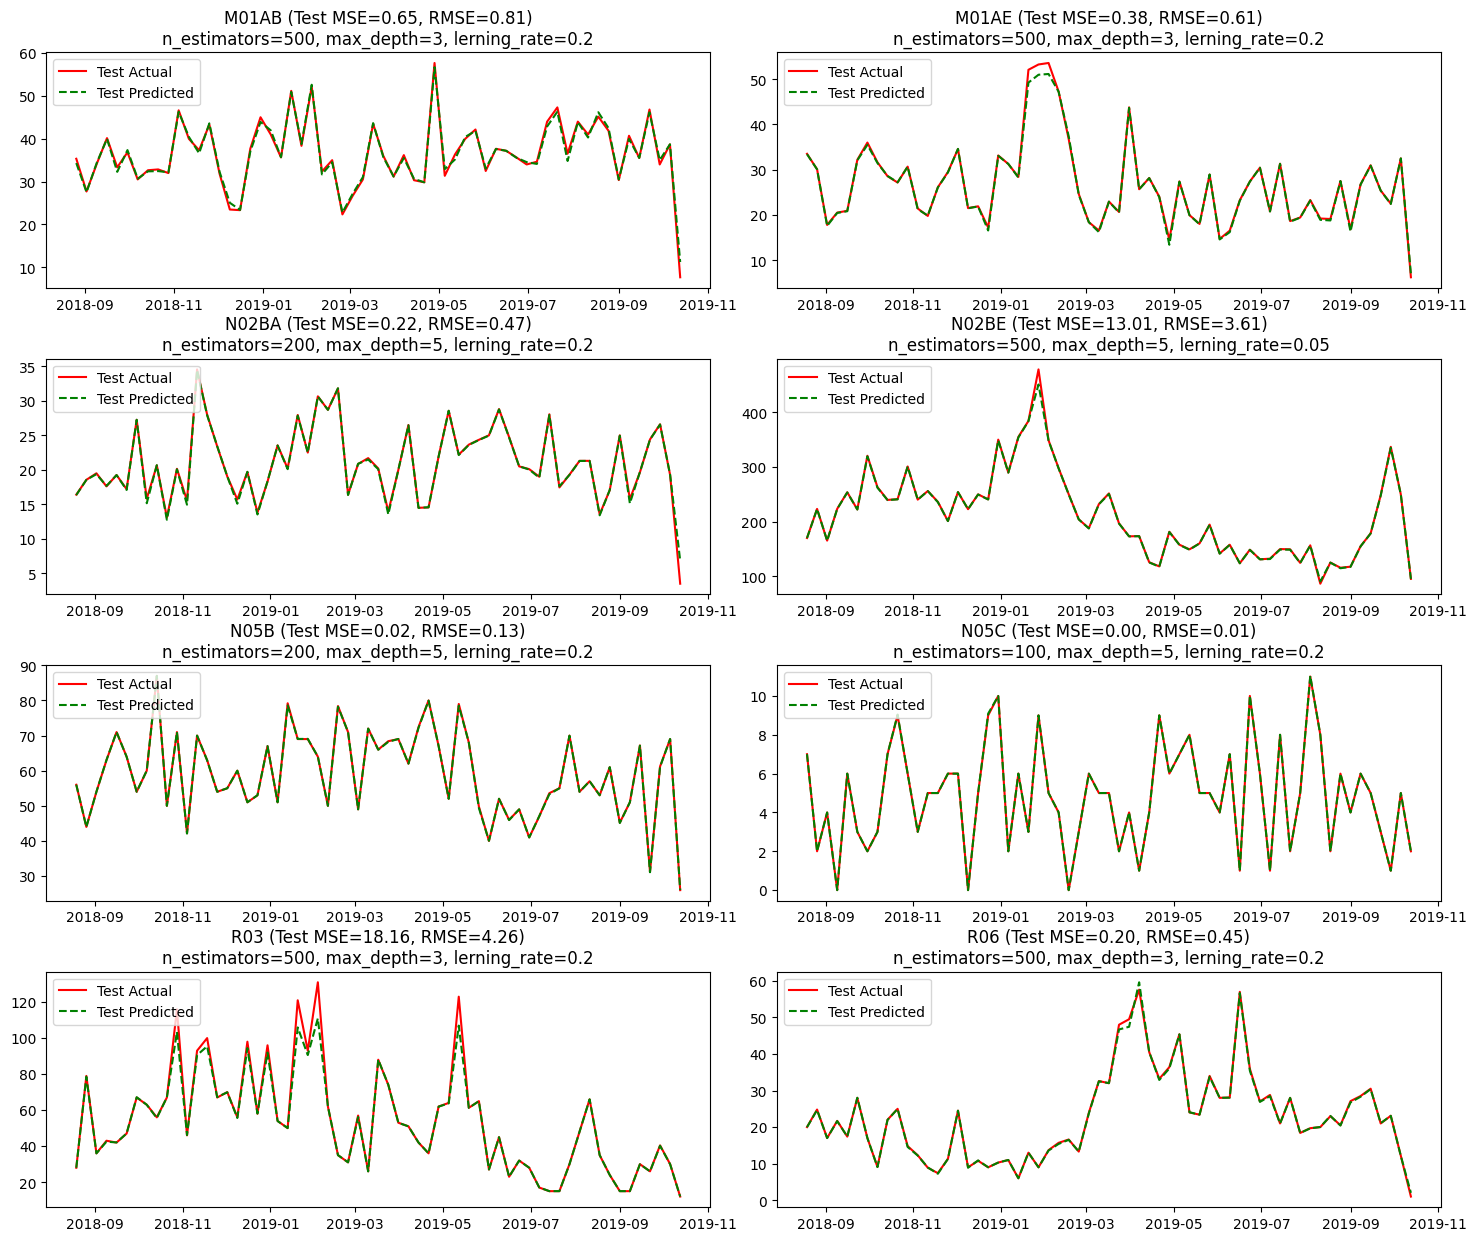

In [13]:
subplotindex = 0
numrows = 4
numcols = 2
fig, ax = plt.subplots(numrows, numcols, figsize=(18, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
warnings.filterwarnings("ignore")

for category in dfTransformed:
    rowindex = subplotindex // numcols
    colindex = subplotindex % numcols

    categoryName = category['category']
    dfgTest = category['dfgTest']
    X_train = category['data']['X_train']
    y_train = category['data']['y_train']
    X_test = category['data']['X_test']
    y_test = category['data']['y_test']

    params = dfResult[dfResult['category'] == categoryName].iloc[0]

    n_estimators = params['n_estimators']
    learning_rate = params['learning_rate']
    max_depth = params['max_depth']

    # Linear Regression model training
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    lr_test_predictions = lr_model.predict(X_test)

    # XGBost model
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=n_estimators, 
        learning_rate=learning_rate,
        max_depth=max_depth,
    )
    xgb_model.fit(X_train, y_train)

    xgb_predictions = xgb_model.predict(X_test)

    hybrid_test_predictions = (lr_test_predictions + xgb_predictions) / 2

    test_rmse = np.sqrt(mean_squared_error(y_test, hybrid_test_predictions))
    test_mse = mean_squared_error(y_test, hybrid_test_predictions)

    # Plot hasil test
    ax[rowindex, colindex].set_title(
        f"{categoryName} (Test MSE={test_mse:.2f}, RMSE={test_rmse:.2f})\nn_estimators={n_estimators}, max_depth={max_depth}, lerning_rate={learning_rate}"
    )
    ax[rowindex, colindex].plot(dfgTest['ds'], dfgTest['y'], 'r-', label='Test Actual')
    ax[rowindex, colindex].plot(dfgTest['ds'], hybrid_test_predictions, 'g--', label='Test Predicted')
    ax[rowindex, colindex].legend(loc='upper left')

    subplotindex += 1

plt.show()


## Optuna

### Code

In [14]:
finalResult = []

def objective(trial, X_train, y_train, X_test, y_test, lr_predictions):
    # Definisikan ruang pencarian hyperparameter
    n_estimators = trial.suggest_int("n_estimators", 50, 500, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, step=0.01)

    # Buat model
    xgb_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        n_jobs=-1,
    )
    xgb_model.fit(X_train, y_train)

    # Prediksi
    xgb_predictions = xgb_model.predict(X_test)
    hybrid_pred = (lr_predictions + xgb_predictions) / 2

    # RMSE
    mse = mean_squared_error(y_test, hybrid_pred)
    rmse = np.sqrt(mse)

    return rmse

# loop per kategori
for category in dfTransformed:
    categoryName = category['category']
    X_train = category['data']['X_train']
    y_train = category['data']['y_train']
    X_test = category['data']['X_test']
    y_test = category['data']['y_test']

    # baseline Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_predictions = lr_model.predict(X_test)

    # study optuna
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, X_train, y_train, X_test, y_test, lr_predictions), n_trials=50,  show_progress_bar=True)

    best_params = study.best_params
    best_value = study.best_value

    finalResult.append({
        "category": categoryName,
        "n_estimators": best_params['n_estimators'],
        "learning_rate": best_params['learning_rate'],
        "max_depth": best_params['max_depth'],
        "value": best_value
    })

dfResult = pd.DataFrame(finalResult)
dfResult

Best trial: 49. Best value: 0.377751: 100%|██████████| 50/50 [00:07<00:00,  6.51it/s]


,category,n_estimators,learning_rate,max_depth,value
0,M01AB,350,0.15,3,0.780269
1,M01AE,500,0.22,10,0.568270
2,N02BA,350,0.21,10,0.455328
3,N02BE,400,0.25,4,3.431346
4,N05B,200,0.21,4,0.125544
5,N05C,450,0.05,7,0.000032
6,R03,350,0.18,10,3.324659
7,R06,300,0.13,5,0.377751


### Visualisasi

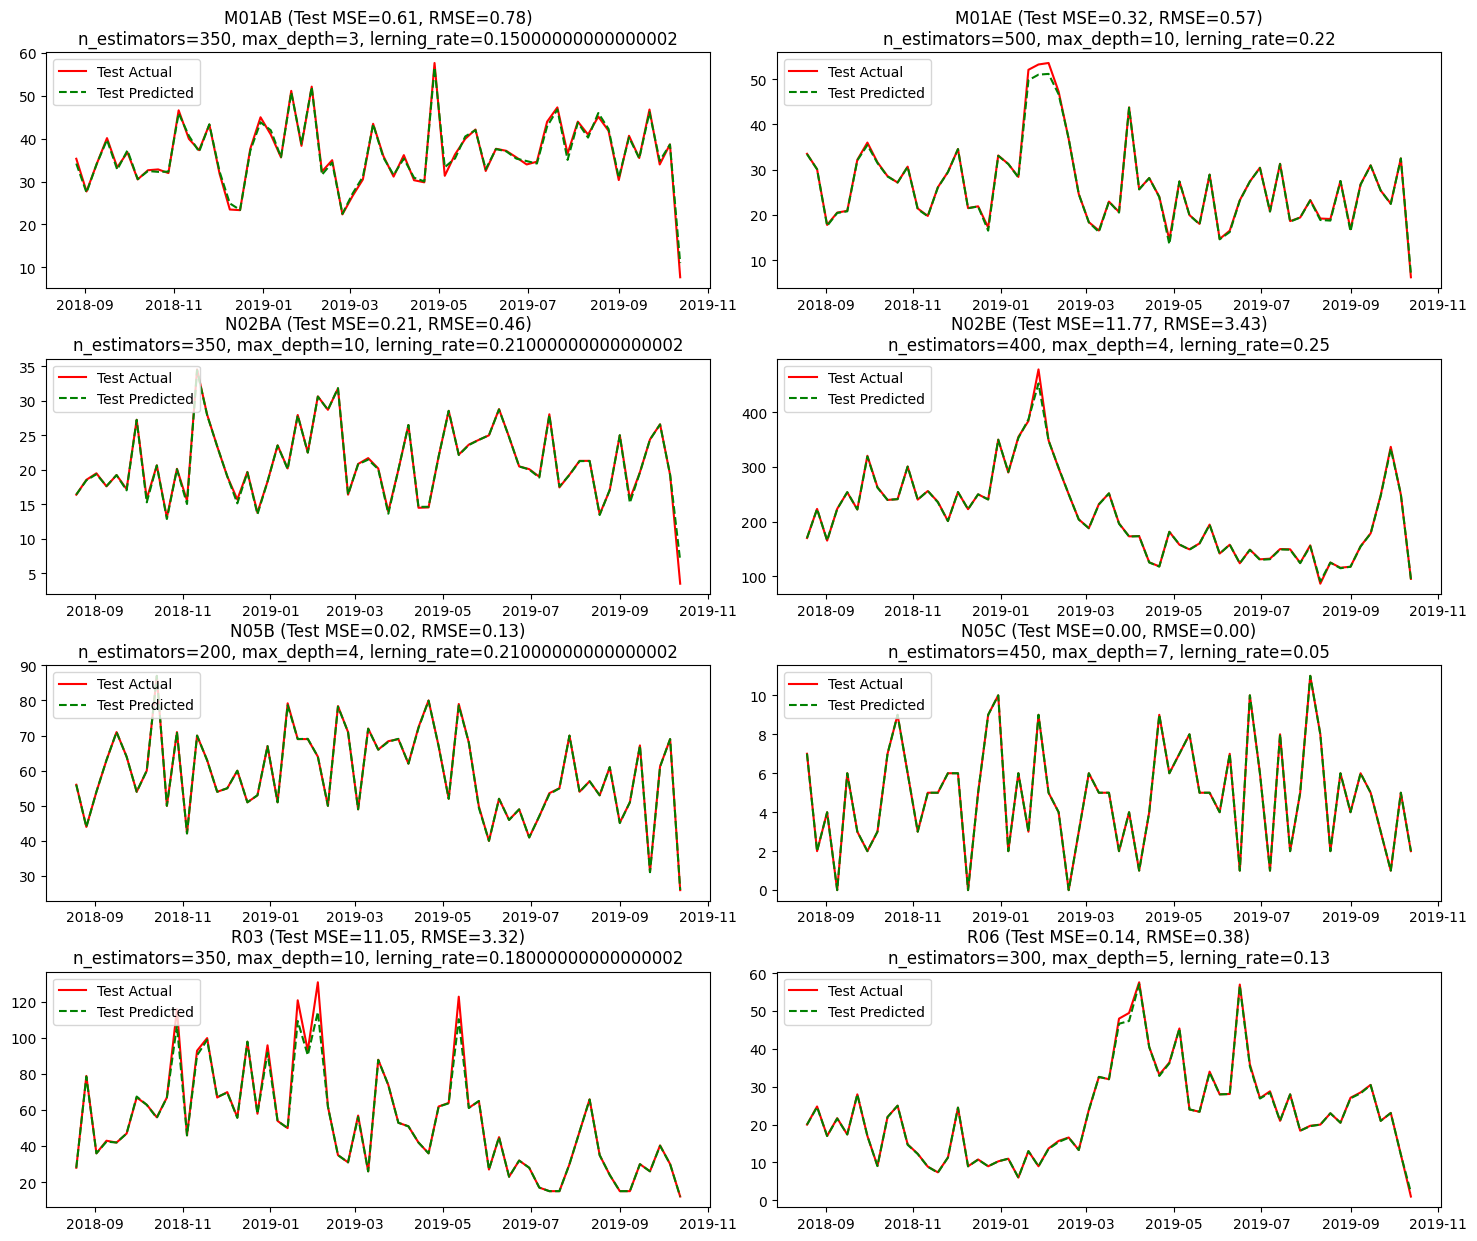

In [15]:
subplotindex = 0
numrows = 4
numcols = 2
fig, ax = plt.subplots(numrows, numcols, figsize=(18, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
warnings.filterwarnings("ignore")

for category in dfTransformed:
    rowindex = subplotindex // numcols
    colindex = subplotindex % numcols

    categoryName = category['category']
    dfgTest = category['dfgTest']
    X_train = category['data']['X_train']
    y_train = category['data']['y_train']
    X_test = category['data']['X_test']
    y_test = category['data']['y_test']

    params = dfResult[dfResult['category'] == categoryName].iloc[0]

    n_estimators = params['n_estimators']
    learning_rate = params['learning_rate']
    max_depth = params['max_depth']

    # Linear Regression model training
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    lr_test_predictions = lr_model.predict(X_test)

    # XGBost model
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=n_estimators, 
        learning_rate=learning_rate,
        max_depth=max_depth,
    )
    xgb_model.fit(X_train, y_train)

    xgb_predictions = xgb_model.predict(X_test)

    hybrid_test_predictions = (lr_test_predictions + xgb_predictions) / 2

    test_rmse = np.sqrt(mean_squared_error(y_test, hybrid_test_predictions))
    test_mse = mean_squared_error(y_test, hybrid_test_predictions)

    # Plot hasil test
    ax[rowindex, colindex].set_title(
        f"{categoryName} (Test MSE={test_mse:.2f}, RMSE={test_rmse:.2f})\nn_estimators={n_estimators}, max_depth={max_depth}, lerning_rate={learning_rate}"
    )
    ax[rowindex, colindex].plot(dfgTest['ds'], dfgTest['y'], 'r-', label='Test Actual')
    ax[rowindex, colindex].plot(dfgTest['ds'], hybrid_test_predictions, 'g--', label='Test Predicted')
    ax[rowindex, colindex].legend(loc='upper left')

    subplotindex += 1

plt.show()


## PSO

### Code

In [16]:
finalResult = []

# Fungsi objektif untuk PSO
def objective_pso(params, X_train, y_train, X_test, y_test, lr_predictions):
    # params shape: (n_particles, n_dimensions)
    # n_estimators, max_depth, learning_rate
    rmse_list = []
    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        learning_rate = float(p[2])

        # Buat model
        xgb_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42,
            n_jobs=-1,
        )
        xgb_model.fit(X_train, y_train)

        # Prediksi
        xgb_predictions = xgb_model.predict(X_test)
        hybrid_pred = (lr_predictions + xgb_predictions) / 2

        mse = mean_squared_error(y_test, hybrid_pred)
        rmse = np.sqrt(mse)
        
        rmse_list.append(rmse)
    return np.array(rmse_list)

# loop per kategori
for category in dfTransformed:
    categoryName = category['category']
    X_train = category['data']['X_train']
    y_train = category['data']['y_train']
    X_test = category['data']['X_test']
    y_test = category['data']['y_test']

    # baseline Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_predictions = lr_model.predict(X_test)

    # batas ruang pencarian hyperparameter
    # [n_estimators, max_depth, learning_rate]
    bounds = (
        [50, 3, 0.01],   # min bound
        [500, 10, 0.3]   # max bound
    )

    optimizer = GlobalBestPSO(
        n_particles=20,
        dimensions=3,
        options={'c1': 0.5, 'c2': 0.3, 'w': 0.9},
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        lambda x: objective_pso(x, X_train, y_train, X_test, y_test, lr_predictions),
        iters=30
    )

    # Ambil hasil terbaik
    best_params = {
        "n_estimators": int(best_pos[0]),
        "max_depth": int(best_pos[1]),
        "learning_rate": float(best_pos[2])
    }

    finalResult.append({
        "category": categoryName,
        "n_estimators": best_params['n_estimators'],
        "learning_rate": best_params['learning_rate'],
        "max_depth": best_params['max_depth'],
        "value": best_cost
    })

dfResult = pd.DataFrame(finalResult)
dfResult


2025-10-18 16:02:31,255 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.746
2025-10-18 16:04:34,134 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.7463055674265198, best pos: [2.60940725e+02 3.61088186e+00 2.35717812e-01]
2025-10-18 16:04:34,151 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.555
2025-10-18 16:06:50,899 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.5548237515661365, best pos: [3.73408192e+02 9.83977561e+00 2.07562226e-01]
2025-10-18 16:06:50,917 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.452
2025-10-18 16:08:11,896 - pyswarms.single.global_best - INFO - Optimization f

,category,n_estimators,learning_rate,max_depth,value
0,M01AB,260,0.235718,3,0.746306
1,M01AE,373,0.207562,9,0.554824
2,N02BA,82,0.293869,9,0.451870
3,N02BE,139,0.232867,5,3.329431
4,N05B,284,0.208829,4,0.122313
5,N05C,444,0.084007,5,0.000029
6,R03,153,0.137162,9,3.321195
7,R06,222,0.212952,7,0.311971


### Visualisasi

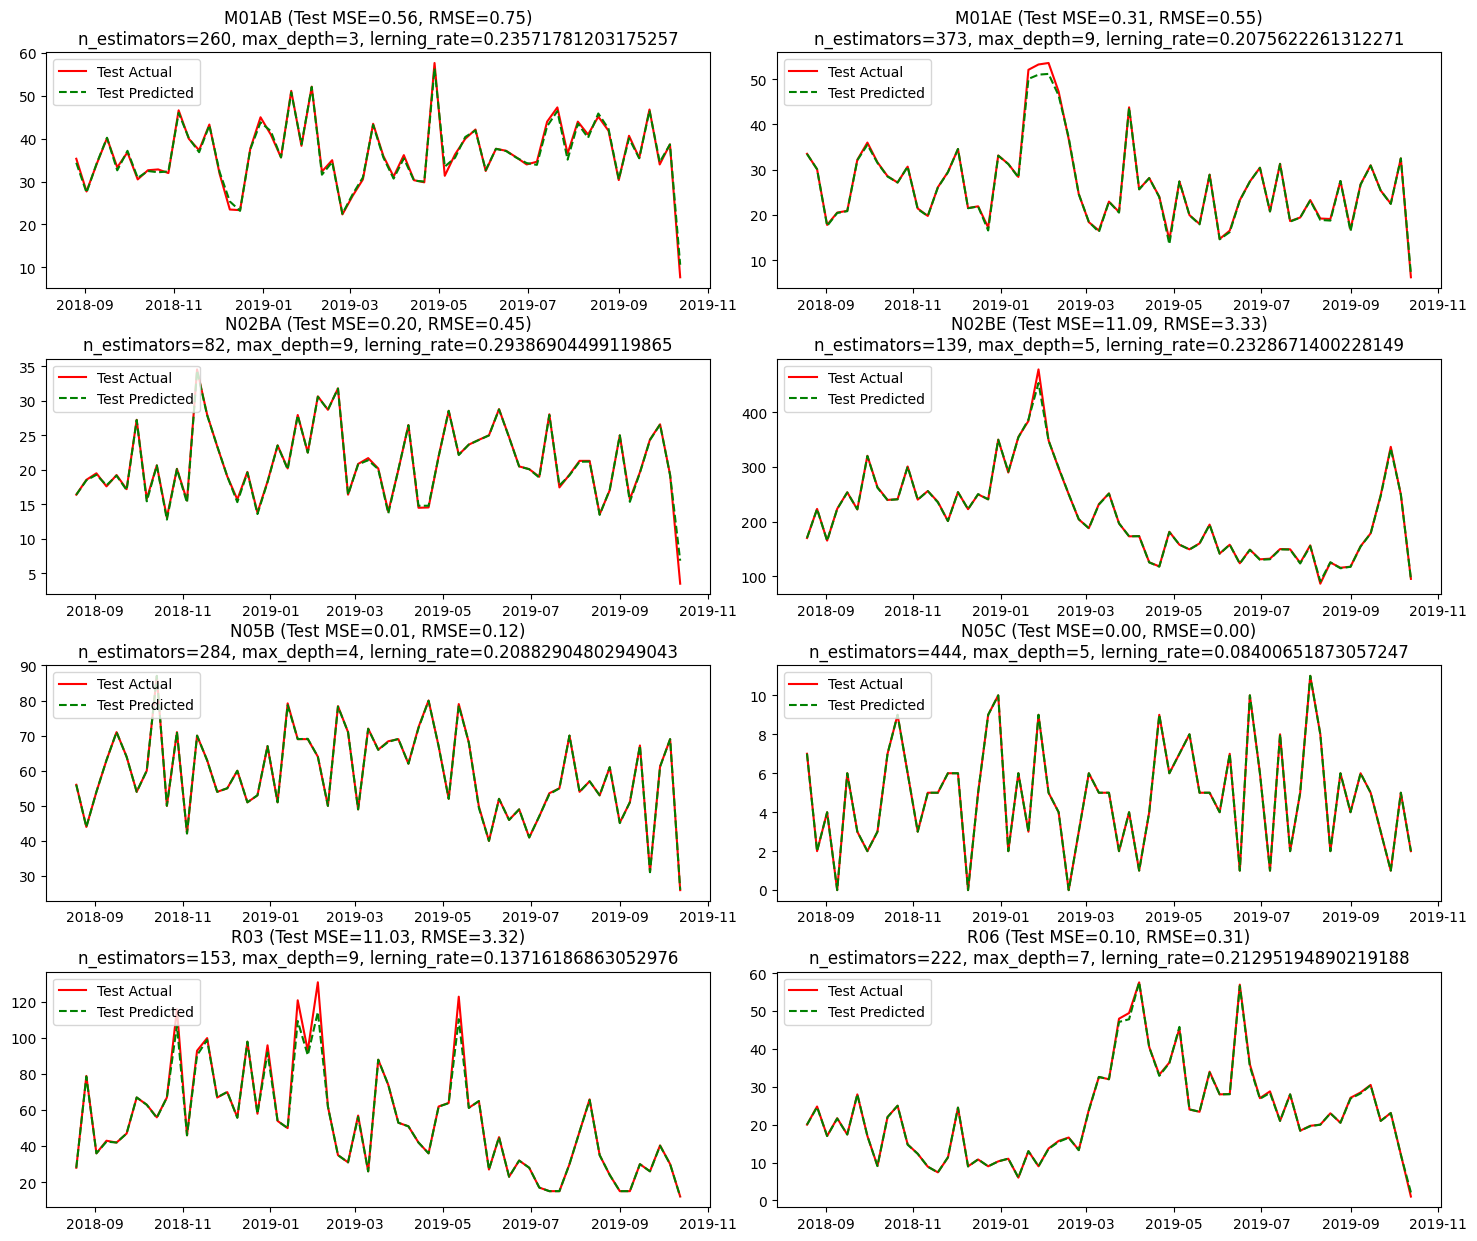

In [17]:
subplotindex = 0
numrows = 4
numcols = 2
fig, ax = plt.subplots(numrows, numcols, figsize=(18, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
warnings.filterwarnings("ignore")

for category in dfTransformed:
    rowindex = subplotindex // numcols
    colindex = subplotindex % numcols

    categoryName = category['category']
    dfgTest = category['dfgTest']
    X_train = category['data']['X_train']
    y_train = category['data']['y_train']
    X_test = category['data']['X_test']
    y_test = category['data']['y_test']

    params = dfResult[dfResult['category'] == categoryName].iloc[0]

    n_estimators = params['n_estimators']
    learning_rate = params['learning_rate']
    max_depth = params['max_depth']

    # Linear Regression model training
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    lr_test_predictions = lr_model.predict(X_test)

    # XGBost model
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=n_estimators, 
        learning_rate=learning_rate,
        max_depth=max_depth,
    )
    xgb_model.fit(X_train, y_train)

    xgb_predictions = xgb_model.predict(X_test)

    hybrid_test_predictions = (lr_test_predictions + xgb_predictions) / 2

    test_rmse = np.sqrt(mean_squared_error(y_test, hybrid_test_predictions))
    test_mse = mean_squared_error(y_test, hybrid_test_predictions)

    # Plot hasil test
    ax[rowindex, colindex].set_title(
        f"{categoryName} (Test MSE={test_mse:.2f}, RMSE={test_rmse:.2f})\nn_estimators={n_estimators}, max_depth={max_depth}, lerning_rate={learning_rate}"
    )
    ax[rowindex, colindex].plot(dfgTest['ds'], dfgTest['y'], 'r-', label='Test Actual')
    ax[rowindex, colindex].plot(dfgTest['ds'], hybrid_test_predictions, 'g--', label='Test Predicted')
    ax[rowindex, colindex].legend(loc='upper left')

    subplotindex += 1

plt.show()


## GEO

### Code

In [18]:
g

Iter 1/30 | Best RMSE: 0.8318
Iter 2/30 | Best RMSE: 0.8318
Iter 3/30 | Best RMSE: 0.7946
Iter 4/30 | Best RMSE: 0.7946
Iter 5/30 | Best RMSE: 0.7748
Iter 6/30 | Best RMSE: 0.7625
Iter 7/30 | Best RMSE: 0.7573
Iter 8/30 | Best RMSE: 0.7573
Iter 9/30 | Best RMSE: 0.7573
Iter 10/30 | Best RMSE: 0.7573
Iter 11/30 | Best RMSE: 0.7573
Iter 12/30 | Best RMSE: 0.7573
Iter 13/30 | Best RMSE: 0.7573
Iter 14/30 | Best RMSE: 0.7573
Iter 15/30 | Best RMSE: 0.7573
Iter 16/30 | Best RMSE: 0.7573
Iter 17/30 | Best RMSE: 0.7573
Iter 18/30 | Best RMSE: 0.7573
Iter 19/30 | Best RMSE: 0.7573
Iter 20/30 | Best RMSE: 0.7573
Iter 21/30 | Best RMSE: 0.7573
Iter 22/30 | Best RMSE: 0.7573
Iter 23/30 | Best RMSE: 0.7573
Iter 24/30 | Best RMSE: 0.7573
Iter 25/30 | Best RMSE: 0.7573
Iter 26/30 | Best RMSE: 0.7573
Iter 27/30 | Best RMSE: 0.7573
Iter 28/30 | Best RMSE: 0.7573
Iter 29/30 | Best RMSE: 0.7573
Iter 30/30 | Best RMSE: 0.7573
Iter 1/30 | Best RMSE: 0.5580
Iter 2/30 | Best RMSE: 0.5558
Iter 3/30 | Best RM

,category,learning_rate,max_depth,n_estimators,rmse
0,M01AB,0.14,3,200,0.757294
1,M01AE,0.29,9,250,0.554928
2,N02BA,0.29,10,450,0.450789
3,N02BE,0.23,5,250,3.312126
4,N05B,0.23,5,450,0.120002
5,N05C,0.08,7,400,0.000029
6,R03,0.14,9,200,3.321036
7,R06,0.21,5,100,0.307440


### Visualisasi

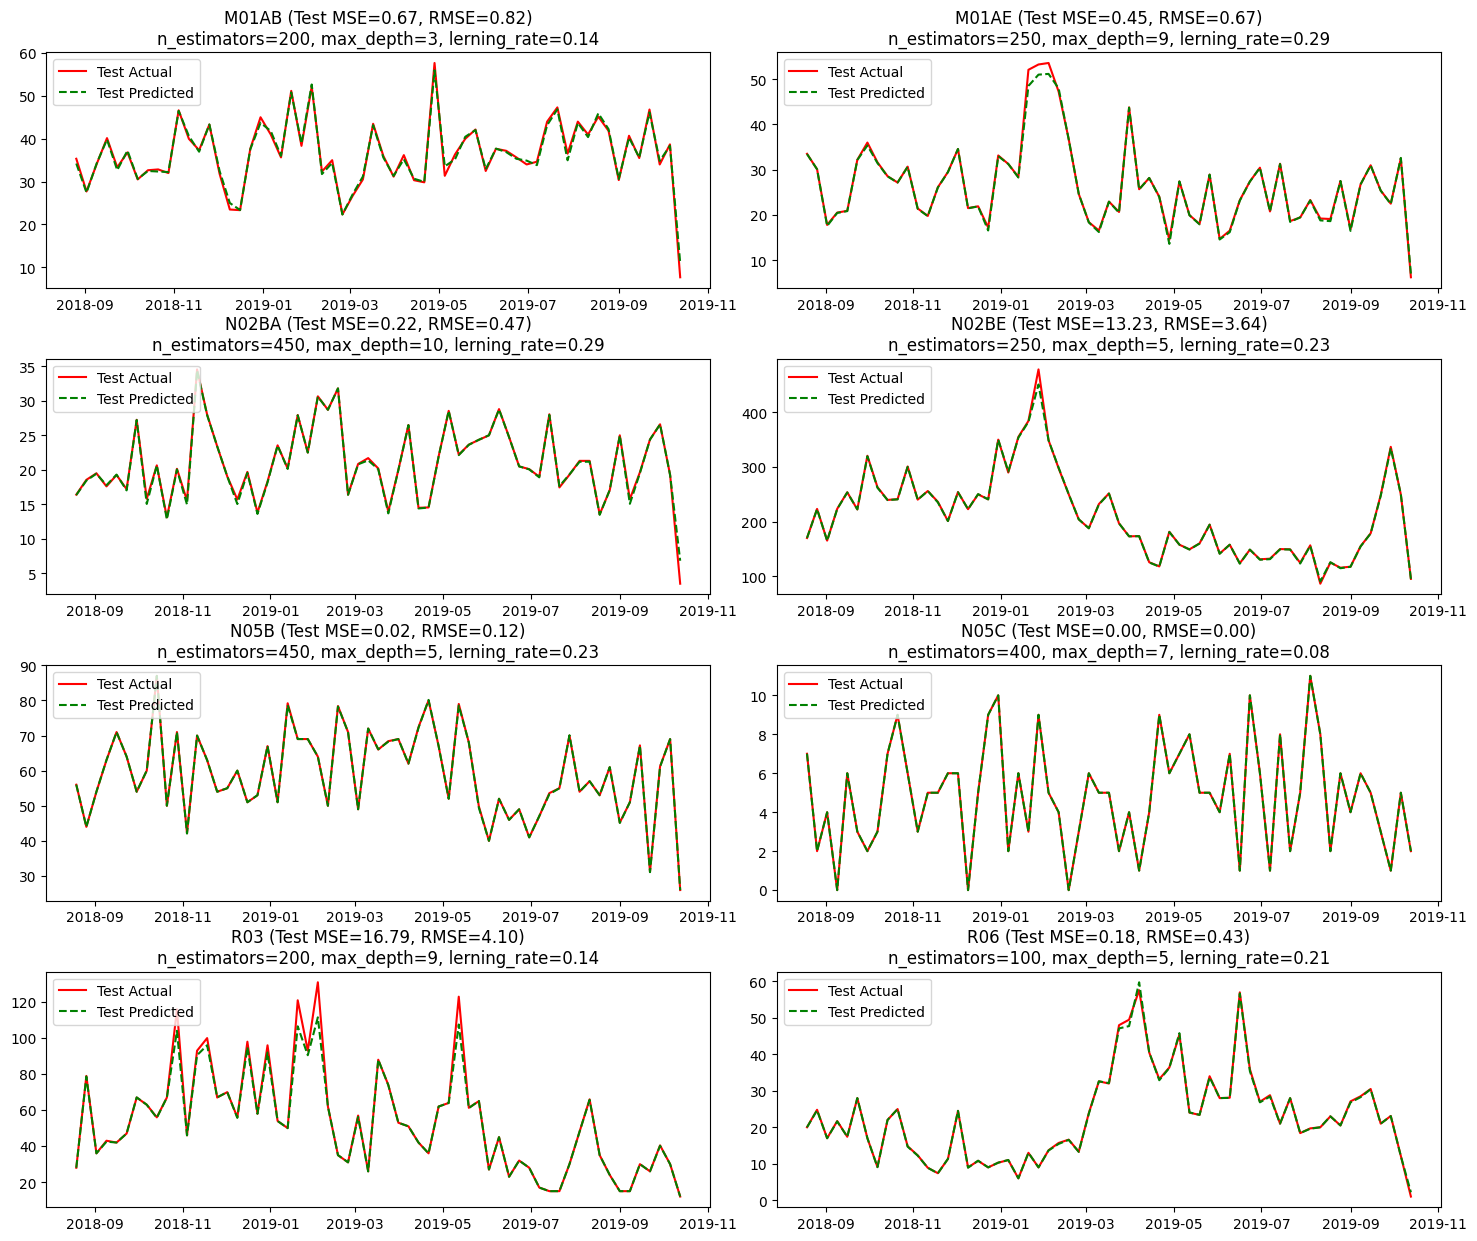

In [19]:
subplotindex = 0
numrows = 4
numcols = 2
fig, ax = plt.subplots(numrows, numcols, figsize=(18, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
warnings.filterwarnings("ignore")

for category in dfTransformed:
    rowindex = subplotindex // numcols
    colindex = subplotindex % numcols

    categoryName = category['category']
    dfgTest = category['dfgTest']
    X_train = category['data']['X_train']
    y_train = category['data']['y_train']
    X_test = category['data']['X_test']
    y_test = category['data']['y_test']

    params = dfResult[dfResult['category'] == categoryName].iloc[0]

    n_estimators = params['n_estimators']
    learning_rate = params['learning_rate']
    max_depth = params['max_depth']

    # Linear Regression model training
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    lr_test_predictions = lr_model.predict(X_test)

    # XGBost model
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=n_estimators, 
        learning_rate=learning_rate,
        max_depth=max_depth,
    )
    xgb_model.fit(X_train, y_train)

    xgb_predictions = xgb_model.predict(X_test)

    hybrid_test_predictions = (lr_test_predictions + xgb_predictions) / 2

    test_rmse = np.sqrt(mean_squared_error(y_test, hybrid_test_predictions))
    test_mse = mean_squared_error(y_test, hybrid_test_predictions)

    # Plot hasil test
    ax[rowindex, colindex].set_title(
        f"{categoryName} (Test MSE={test_mse:.2f}, RMSE={test_rmse:.2f})\nn_estimators={n_estimators}, max_depth={max_depth}, lerning_rate={learning_rate}"
    )
    ax[rowindex, colindex].plot(dfgTest['ds'], dfgTest['y'], 'r-', label='Test Actual')
    ax[rowindex, colindex].plot(dfgTest['ds'], hybrid_test_predictions, 'g--', label='Test Predicted')
    ax[rowindex, colindex].legend(loc='upper left')

    subplotindex += 1

plt.show()
